## Part 1: Setting Up the Problem
**Advanced Methods in Natural Language Processing — Final Project**
*Barcelona School of Economics*

---

This notebook addresses the first stage of the project: understanding the dataset and establishing baseline performance benchmarks. 

The dataset used is the **Mental Health Condition Classification** dataset from HuggingFace (`sai1908/Mental_Health_Condition_Classification`), which contains ~103k text samples labeled across 7 mental health conditions.

The notebook is structured as follows:
- **1a. Bibliography & State of the Art:** Overview of the task and relevant benchmarks in mental health NLP.
- **1b. Dataset Description:** Exploratory analysis including class distribution and descriptive statistics.
- **1c. Random Classifier:** Implementation of a random baseline to set a performance floor.
- **1d. Rule-Based Baseline:** A keyword-driven classifier evaluated against the random baseline.

## 1.a Bibliography & State of the Art
Mental health text classification is the task of automatically identifying mental health conditions from text. This has clear real-world applications. Think of chatbots that can detect early signs of anxiety or depression, or tools that help clinicians prioritize patients based on what they write. According to the WHO, nearly 970 million people worldwide live with a mental disorder, which makes automated, scalable detection tools especially relevant.


### What has been done so far?

Looking at the literature, the field has clearly moved from simple methods like Logistic Regression and SVM toward transformer-based models. The reason is mental health language is subtle and context-dependent, and bag-of-words approaches just can't capture that. LSTM models were a step forward, but as Hasan et al. (2025) show, they fail badly when using static embeddings like Word2Vec or GloVe , F1 scores close to 0% in some classes. BERT changed this completely. By reading text in both directions and leveraging large-scale pretraining, fine-tuned BERT models consistently reach 90%+ accuracy in this domain. More recent work has explored variants like RoBERTa and DistilBERT, all building on the same transformer foundation.

### Benchmarks

| Model | Task | Accuracy | F1 | Reference |
|-------|------|----------|----|-----------|
| BERT fine-tuned | Mental health classification (our dataset) | **96.6%** | — | Elite13, HuggingFace |
| BERT-base | 7-class mental health (Kaggle) | 90.0% | — | Springer, 2026 |
| BERT | Binary mental health classification | 0.95 | 0.95 | Hrnjić & Altoka, IJCA 2026 |
| Logistic Regression + TF-IDF | Binary mental health classification | 0.92 | 0.92 | Hrnjić & Altoka, IJCA 2026 |
| RoBERTa | Multi-class mental health (Reddit, 7 classes) | — | 0.91–0.99 | Hasan et al., arXiv 2025 |
| BERT fine-tuned | 7-class mental health classification | 94.83% | 94.80% | Sevinç, arXiv 2025 |
| Logistic Regression | 7-class mental health classification | 86.80% | 87.00% | Sevinç, arXiv 2025 |

### Key takeaways

1. **Transformers dominate**: BERT and its variants consistently outperform traditional ML methods and LSTM-based models across all reviewed studies.
2. **Context matters**: Static embeddings (Word2Vec, GloVe) fail almost completely in this domain, with F1 scores near 0% in some cases. Mental health language is highly context-dependent.
3. **Our ceiling**: The best result on our exact dataset is 96.6% accuracy using a fine-tuned BERT model. This is our state-of-the-art reference for Part 3.
4. **The limited data challenge**: Most benchmarks use full datasets. A key open question, and the focus of Part 2 ,is how much performance degrades with only 32 labeled examples.

### References

- Hrnjić, A. & Altoka, Z. (2026). *BERT vs. Logistic Regression: Classifying Mental Health-Related Text using Machine Learning and NLP*. International Journal of Computer Applications, 187(104).
- Hasan, K., Saquer, J. & Zhang, Y. (2025). *Mental Multi-class Classification on Social Media: Benchmarking Transformer Architectures against LSTM Models*. arXiv:2509.16542.
- Sevinç, K. (2025). *A new training approach for text classification in Mental Health: LatentGLoss*. arXiv:2504.07245.
- Elite13. (2025). *bert-finetuned-mental-health*. HuggingFace. https://huggingface.co/Elite13/bert-finetuned-mental-health
- BERT-Based Text Classification Pipeline for Categorising Mental Health Statements. Springer, 2026.

## 1.b Dataset Description

In [1]:
from datasets import load_dataset
import pandas as pd
import random
import numpy as np

random.seed(42)
np.random.seed(42)

dataset = load_dataset("sai1908/Mental_Health_Condition_Classification")
df = pd.DataFrame(dataset['train'])
df.head()

README.md:   0%|          | 0.00/791 [00:00<?, ?B/s]

Mental Health Text Dataset for Emotion a(…):   0%|          | 0.00/46.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/103488 [00:00<?, ? examples/s]

,text,status
0,"""My mind is a never-ending cycle of worry, and...",anxiety
1,Despite the sun shining and birds singing outs...,bipolar
2,"I'm drowning in responsibilities, each one dem...",stress
3,"""My emotions shift like the wind, leaving me u...",personality disorder
4,"I'm trapped in a whirlwind of thoughts, unable...",anxiety


Total samples: 103488
Number of classes: 7

Class distribution:
                      Count  Percentage
status                                 
anxiety               17620       17.03
normal                16068       15.53
depression            15901       15.37
stress                15230       14.72
personality disorder  13915       13.45
bipolar               13708       13.25
suicidal              11046       10.67


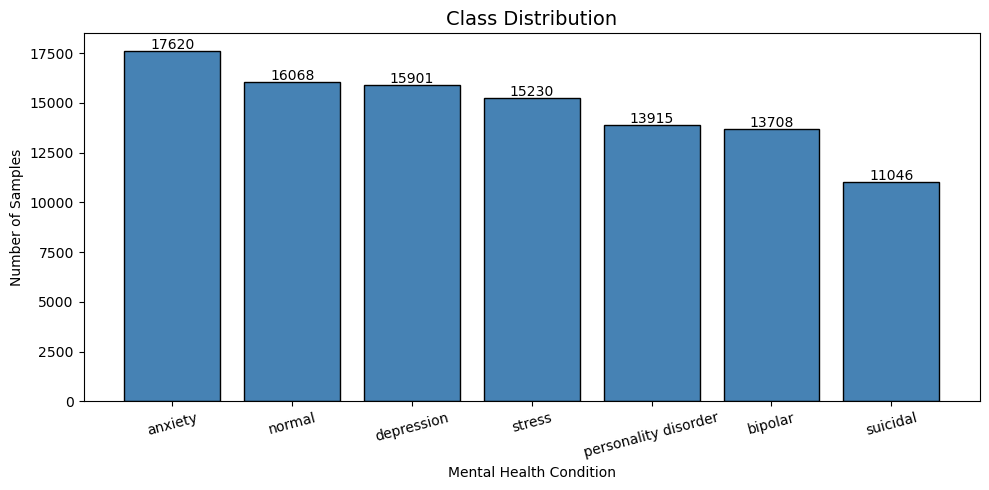

In [2]:
# Dataset size and class distribution
print(f"Total samples: {len(df)}")
print(f"Number of classes: {df['status'].nunique()}")
print(f"\nClass distribution:")

class_counts = df['status'].value_counts()
class_pct = df['status'].value_counts(normalize=True) * 100

class_dist = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_pct.round(2)
})
print(class_dist)

# Bar plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(class_counts.index, class_counts.values, color='steelblue', edgecolor='black')
plt.title('Class Distribution', fontsize=14)
plt.xlabel('Mental Health Condition')
plt.ylabel('Number of Samples')
plt.xticks(rotation=15)
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

The dataset contains 103,488 samples across 7 mental health conditions: anxiety, normal, depression, stress, personality disorder, bipolar, and suicidal. The class distribution is relatively balanced , the largest class (anxiety, 17.03%) is only 1.6x the smallest (suicidal, 10.67%). This is good news for model training, as we won't need aggressive resampling strategies to handle class imbalance. 

However, it is worth noting that the `suicidal` class is the least represented, which may affect performance on that specific category. One thing that stands out is the presence of a `normal` class (15.53%), which represents text with no mental health condition. This adds an important dimension to the classification task , the model must not only distinguish between different conditions, but also identify when no condition is present.

Text length statistics (characters):
count    103488.00
mean        435.45
std         657.80
min           2.00
25%         135.00
50%         198.00
75%         547.00
max       27588.00
Name: text_length, dtype: float64

Word count statistics:
count    103488.00
mean         82.02
std         127.86
min           1.00
25%          24.00
50%          34.00
75%          99.00
max        5419.00
Name: word_count, dtype: float64


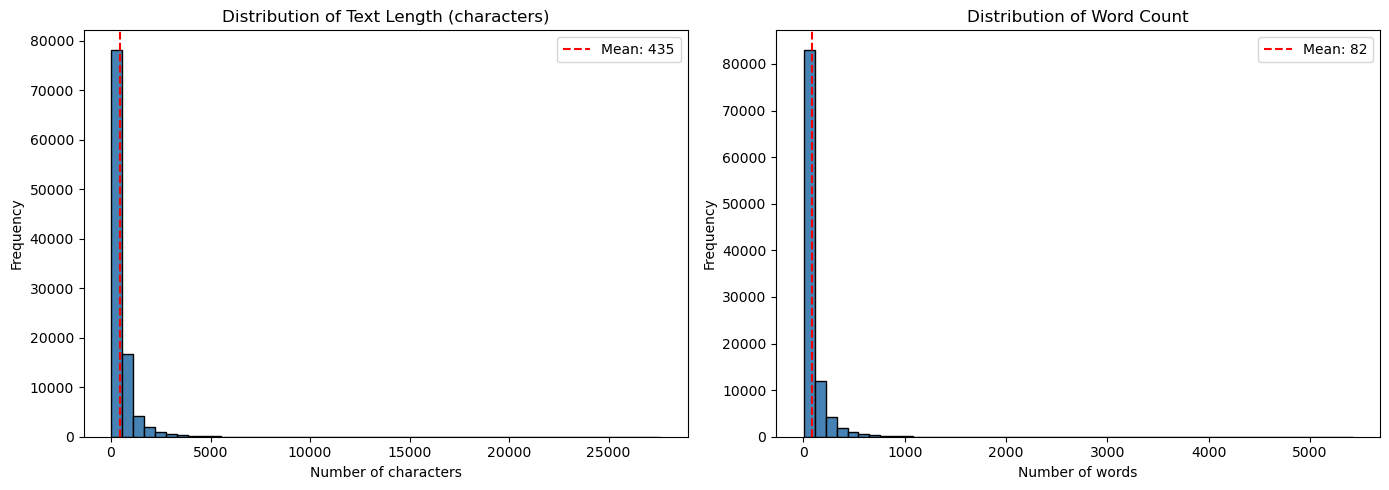


Average word count per class:
status
depression              175.4
suicidal                152.3
anxiety                  72.9
bipolar                  67.7
personality disorder     54.3
stress                   50.3
normal                   17.6
Name: word_count, dtype: float64


In [3]:
# Text length analysis
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print("Text length statistics (characters):")
print(df['text_length'].describe().round(2))

print("\nWord count statistics:")
print(df['word_count'].describe().round(2))

# Distribution of text lengths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Characters
axes[0].hist(df['text_length'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Text Length (characters)')
axes[0].set_xlabel('Number of characters')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['text_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['text_length'].mean():.0f}")
axes[0].legend()

# Words
axes[1].hist(df['word_count'], bins=50, color='steelblue', edgecolor='black')
axes[1].set_title('Distribution of Word Count')
axes[1].set_xlabel('Number of words')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f"Mean: {df['word_count'].mean():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

# Average text length per class
print("\nAverage word count per class:")
print(df.groupby('status')['word_count'].mean().round(1).sort_values(ascending=False))

The dataset shows high variability in text length. While the median text is only 198 characters (34 words), the mean is 435 characters (82 words), pulled up by a small number of very long texts , the longest reaching 27,588 characters. This right-skewed distribution is visible in both histograms. This has a direct implication for BERT, since it has a maximum input limit of 512 tokens, a portion of the longer texts will be truncated during tokenization. This is particularly relevant for the `depression` and `suicidal` classes, which have the highest average word counts (175 and 152 words respectively).

The average word count per class reveals something interesting, `normal` texts are shorter (17.6 words on average) compared to all other classes. This makes intuitive sense , people describing a mental health condition tend to elaborate more than someone writing a neutral statement. This length difference could serve as a useful signal for the classifier, especially for separating `normal` from the rest.

On the other hand, classes like `stress`, `personality disorder`, `bipolar`, and `anxiety` are closer to each other in length, which suggests the classifier will need to rely more on semantic content than text length to distinguish between them.

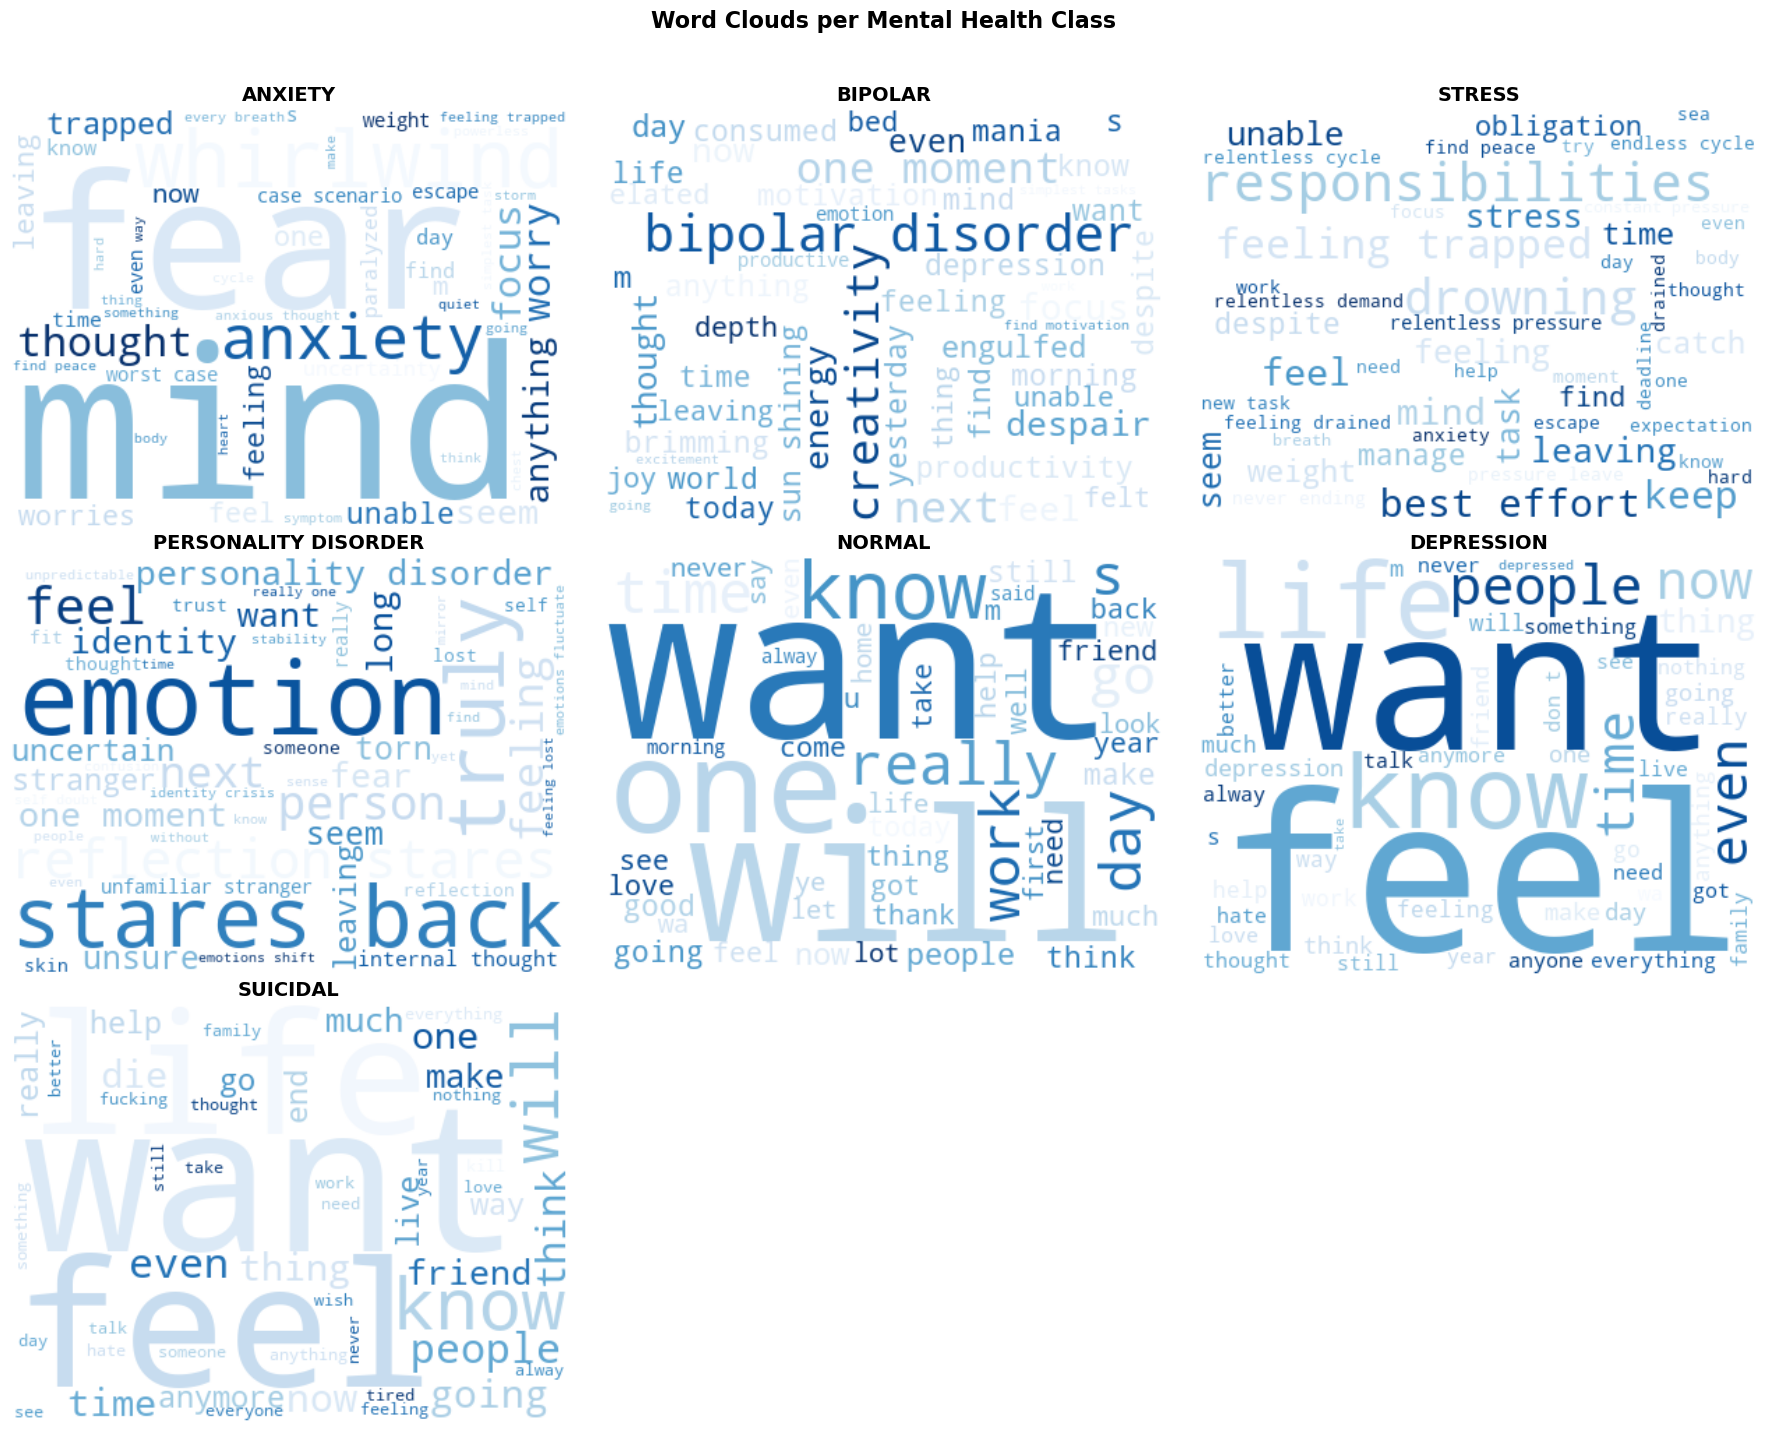

In [5]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, label in enumerate(df['status'].unique()):
    text = ' '.join(df[df['status'] == label]['text'].values)
    wordcloud = WordCloud(
        width=400, height=300,
        background_color='white',
        max_words=50,
        colormap='Blues'
    ).generate(text)
    
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'{label.upper()}', fontsize=14, fontweight='bold')
    axes[i].axis('off')

# Hide the last empty subplot (7 classes, 9 subplots)
axes[7].axis('off')
axes[8].axis('off')

plt.suptitle('Word Clouds per Mental Health Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# Sample examples per class
print("Sample examples per class:\n")
for label in df['status'].unique():
    print(f"{'='*60}")
    print(f"CLASS: {label.upper()}")
    print(f"{'='*60}")
    samples = df[df['status'] == label]['text'].sample(2, random_state=42).values
    for i, sample in enumerate(samples, 1):
        print(f"\nExample {i}:\n{sample[:300]}...")
    print()

Sample examples per class:

CLASS: ANXIETY

Example 1:
"every thought that enters my mind feels like a heavy burden, and i'm unable to shake the fear that something terrible is just around the corner."...

Example 2:
"my mind is a never-ending storm of worries, and i'm drowning in the fear of what might go wrong."...

CLASS: BIPOLAR

Example 1:
bp friends? due to my bp ups and downs i've lost as well as have had to cut out almost all my friends from my life because of toxicity in the friendship. i'm looking to form friendships if possible here with people who can relate. feel free to message me if you're looking for a friend, a listening e...

Example 2:
"last week, i was engrossed in a creative project, brimming with inspiration and focus. now, i'm stuck in a deep, debilitating depression, unable to muster the energy or motivation to do even the simplest tasks."...

CLASS: STRESS

Example 1:
the psychology of horror movies: why people enjoy being scared, shocked, and disgusted while f

Looking at the examples and word clouds per class, a few patterns stand out:

**Classes with distinct vocabulary:**
- **Bipolar** is the easiest to identify visually, words like "mania", "creativity", "productivity", "brimming" alongside "despair" and "depth" reflect the characteristic mood swings. The contrast between high-energy and low-energy language is unique to this class.
- **Stress** centers around external pressure , "responsibilities", "obligations", "deadlines", "relentless cycle". The language is more task-oriented compared to other classes.
- **Personality Disorder** has a identity-related vocabulary , "identity", "emotion", "uncertain", "stranger", "unfamiliar", "torn". This is quite distinct from the other classes.
- **Normal** is the most neutral , common words like "want", "know", "work", "day" with no emotional distress markers.

**Classes with overlapping vocabulary:**
- **Anxiety**, **Depression**, and **Suicidal** share a lot of common words: "feel", "want", "know", "mind", "trapped". This overlap is a major challenge for classification , a phrase like "I feel trapped and want to escape" could plausibly belong to any of these three classes.
- **Suicidal** does show some unique markers ("die", "end", "live") but many of its most frequent words are shared with Depression.

**A note on data quality:**
Looking at the stress examples, one sample reads "i cannot think straight, i hear failure and want to hurt myself" , which semantically belongs more to the suicidal category. This suggests some label noise in the dataset, which could affect model performance, particularly on the boundary cases between classes.


## 1.c Random Classifier

Before testing any real model, it is useful to establish the performance of a random classifier , one that assigns labels purely by chance. This gives us a performance floor, any model we build should do better than this, otherwise it is not learning anything useful. For a perfectly balanced dataset with 7 classes, you'd expect to be right about 1 in 7 times (14.3%). But since our dataset is slightly imbalanced, we calculate the actual expected performance by running 1000 random simulations and averaging the results.

In [6]:
from sklearn.model_selection import train_test_split

# Split dataset: 64% train, 16% val, 20% test
texts = df['text'].values
labels = df['status'].values

X_temp, X_test, y_temp, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print(f"Train:      {len(X_train):,} samples ({len(X_train)/len(df)*100:.1f}%)")
print(f"Validation: {len(X_val):,} samples ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test:       {len(X_test):,} samples ({len(X_test)/len(df)*100:.1f}%)")

Train:      66,232 samples (64.0%)
Validation: 16,558 samples (16.0%)
Test:       20,698 samples (20.0%)


Random Classifier (1000 simulations):
Expected Accuracy: 0.1453 ± 0.0024
Expected Macro F1: 0.1428 ± 0.0024


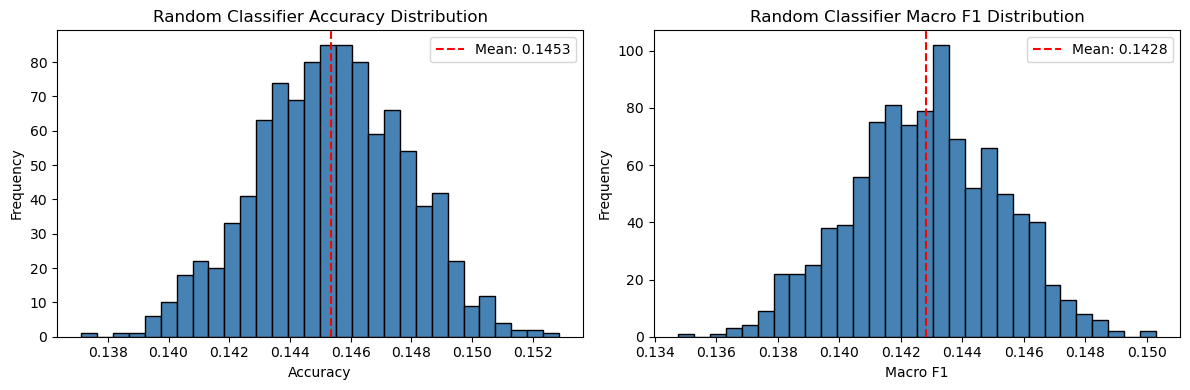

In [7]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

unique_classes = np.unique(labels)
class_proportions = [np.mean(labels == c) for c in unique_classes]

# 1000 simulations
accuracies = []
f1_scores = []

for _ in range(1000):
    random_preds = np.random.choice(
        unique_classes, 
        size=len(y_test), 
        p=class_proportions  # respeta las proporciones reales del dataset
    )
    accuracies.append(accuracy_score(y_test, random_preds))
    f1_scores.append(f1_score(y_test, random_preds, average='macro'))

print(f"Random Classifier (1000 simulations):")
print(f"Expected Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"Expected Macro F1: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")

# Histogram
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(accuracies, bins=30, color='steelblue', edgecolor='black')
plt.axvline(np.mean(accuracies), color='red', linestyle='--', label=f"Mean: {np.mean(accuracies):.4f}")
plt.title('Random Classifier Accuracy Distribution')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(f1_scores, bins=30, color='steelblue', edgecolor='black')
plt.axvline(np.mean(f1_scores), color='red', linestyle='--', label=f"Mean: {np.mean(f1_scores):.4f}")
plt.title('Random Classifier Macro F1 Distribution')
plt.xlabel('Macro F1')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

The random classifier achieves an expected accuracy of **14.53%** and a macro F1 of **14.28%** across 1000 simulations. Both metrics are very stable, the standard deviation is only ±0.0024, which confirms that these numbers are reliable estimates and not a product of luck in a single run. The result is close to the theoretical 1/7 ≈ 14.3%, which makes sense given that our dataset is relatively balanced across the 7 classes. These numbers set our performance floor, any classifier we build in the following sections must beat 14.53% accuracy and 14.28% macro F1 to demonstrate that it is actually learning something from the text. 

## 1.d Baseline Implementation

A rule-based classifier assigns a class to each text based on the presence of predefined keywords , no learning involved. This is the simplest possible approach that actually uses the text content, and it serves as a more meaningful baseline than the random classifier.

The keywords were selected by looking at real examples from the dataset and the word clouds generated in section 1b. The hypothesis is that some classes will be easier to capture this way (bipolar, suicidal) because they have more distinctive vocabulary, while others like anxiety, stress and depression will be harder since they share a lot of common words. 

One known limitation upfront, when a text matches keywords from multiple classes, the classifier has to pick one. And when no keywords match, it defaults to the most frequent class (anxiety). This will likely hurt performance on the overlapping classes.

In [8]:
# Rule-based classifier using keywords from dataset examples and word clouds
def rule_based_classifier(text):
    text = text.lower()
    
    # Keyword dictionary per class
    keywords = {
        'suicidal': ['suicide', 'suicidal', 'want to die', 'end my life', 
                     'kill myself', 'no reason to live', 'better off dead',
                     'want to end', 'take my life'],
        
        'bipolar': ['bipolar', 'mania', 'manic', 'mood swings', 
                    'bp ups and downs', 'depressive episode', 'hypomanic',
                    'creativity', 'productivity', 'brimming'],
        
        'personality disorder': ['personality disorder', 'identity crisis',
                                  'unfamiliar', 'stranger to myself', 
                                  'identity', 'emotion fluctuates',
                                  'uncertain who i am', 'torn'],
        
        'depression': ['depression', 'depressed', 'hopeless', 'worthless',
                       'no reason to go on', 'empty inside', 'numb',
                       'cannot get out of bed', 'darkness'],
        
        'anxiety': ['anxiety', 'anxious', 'panic attack', 'overthinking',
                    'worst case scenario', 'constant worry', 'fear of',
                    'nervous', 'restless'],
        
        'stress': ['stress', 'stressed', 'overwhelmed', 'responsibilities',
                   'deadlines', 'obligations', 'pressure', 'burnout',
                   'relentless'],
        
        'normal': ['had a good day', 'feeling good', 'happy', 'grateful',
                   'excited', 'looking forward', 'doing well']
    }
    
    # Count keyword matches per class
    scores = {label: 0 for label in keywords}
    for label, words in keywords.items():
        for word in words:
            if word in text:
                scores[label] += 1
    
    # Return class with most matches, default to 'anxiety' if no match
    best_class = max(scores, key=scores.get)
    if scores[best_class] == 0:
        return 'anxiety'
    return best_class

# Apply to test set
y_pred_rules = [rule_based_classifier(text) for text in X_test]

Rule-Based Classifier Results:
Accuracy: 0.5254
Macro F1: 0.5222

Classification Report:
                      precision    recall  f1-score   support

             anxiety       0.29      0.88      0.43      3524
             bipolar       0.94      0.73      0.82      2742
          depression       0.65      0.35      0.45      3180
              normal       0.19      0.02      0.04      3214
personality disorder       0.96      0.43      0.59      2783
              stress       0.82      0.82      0.82      3046
            suicidal       0.62      0.42      0.50      2209

            accuracy                           0.53     20698
           macro avg       0.64      0.52      0.52     20698
        weighted avg       0.62      0.53      0.51     20698



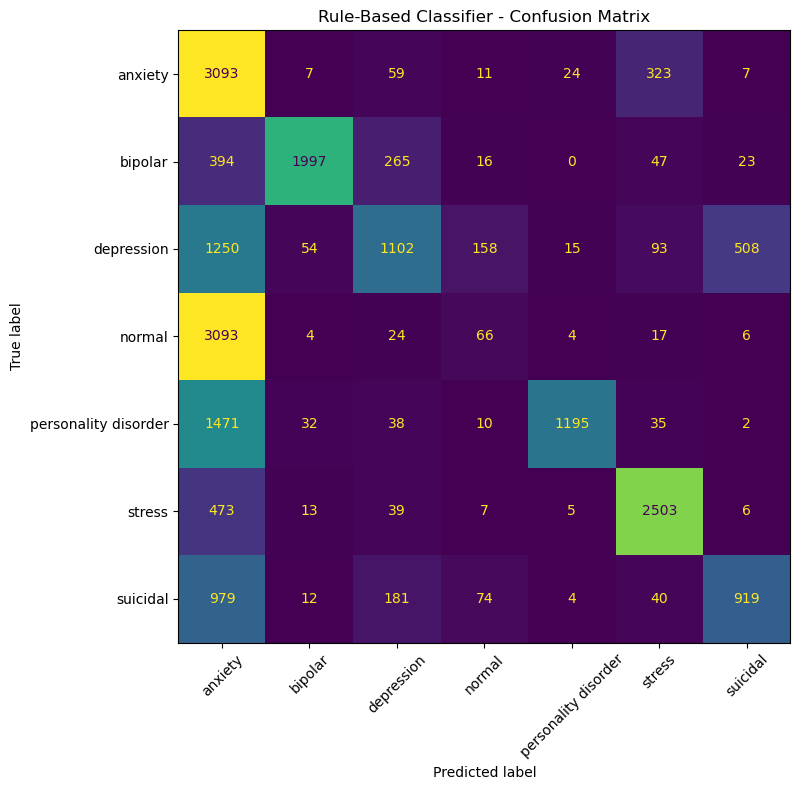

In [10]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay, confusion_matrix

# Metrics
accuracy = accuracy_score(y_test, y_pred_rules)
macro_f1 = f1_score(y_test, y_pred_rules, average='macro')

print(f"Rule-Based Classifier Results:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rules))

# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rules,
    ax=ax,
    xticks_rotation=45,
    colorbar=False
)
plt.title('Rule-Based Classifier - Confusion Matrix')
plt.tight_layout()
plt.show()

The rule-based classifier achieves 52.54% accuracy and 0.52 macro F1 , well above the random baseline of 14.53% and 0.14, which confirms that keyword matching captures real signal in the text. However, the results vary significantly across classes.

**What worked well:**
- **Bipolar (F1=0.82)** and **Stress (F1=0.82)** are the best classified classes. This matches our hypothesis from the word clouds ,both have distinctive vocabulary that doesn't overlap much with other classes. Words like "mania", "mood swings", "brimming" for bipolar and "responsibilities", "deadlines", "relentless" for stress are strong discriminators.
- **Personality disorder (precision=0.96)**  when the classifier predicts this class, it is almost always right. The identity-related vocabulary ("identity crisis", "stranger to myself") is quite unique.

**What didn't work:**
- **Normal (F1=0.04)** is the worst performing class. This makes sense , normal texts don't contain mental health keywords, so the classifier almost never predicts it. Out of 3,214 normal texts, only 66 were correctly identified.
- **Anxiety** is being used as a catch-all , whenever no keywords match, the text defaults to anxiety. This gives it a high recall (0.88) but very low precision (0.29), meaning most anxiety predictions are actually wrong.
- **Depression** is heavily confused with anxiety and suicidal, confirming the semantic overlap we identified in the word clouds. A phrase like "I feel hopeless and want to disappear" could genuinely belong to either class.

**Key limitation:**
The fundamental problem with a rule-based approach is that mental health language is highly contextual. The same word can mean very different things depending on context . "I want to die laughing" vs "I want to die". A keyword matcher cannot capture this distinction, which is exactly why models like BERT, which read the full context, perform so much better in this domain.

**Note on data leakage:** the keywords were informed by word clouds generated on the full dataset before splitting. Ideally, this analysis should be restricted to the training set. For a rule-based baseline this is a minor concern since the keywords reflect general clinical knowledge, but it is worth acknowledging.